# 04 — SHAP: Feature Importance + Individual Explanations

Goals:
1. Global feature importance — which sensors matter most overall?
2. Summary plot — feature value direction (high tool wear → increased failure risk)
3. Individual explanation — explain a specific predicted failure (tie to physics)

Interview story:
> 'The SHAP analysis highlighted power, rotational speed, tool wear, and torque —
> consistent with mechanical stress and accumulated wear physics.'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
import sys; sys.path.insert(0, '..')
from src.features import load_raw, build_features, get_X_y
from src.model import FailureClassifier

%matplotlib inline
shap.initjs()

In [2]:
df = build_features(load_raw())
X, y = get_X_y(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = FailureClassifier.load('../models/')
X_test_scaled = clf.scaler.transform(X_test)
X_test_df_scaled = pd.DataFrame(X_test_scaled, columns=clf.feature_names)

[features] Loaded 10,000 rows | Failure rate: 3.4%


In [3]:
# Global SHAP values
explainer = shap.TreeExplainer(clf.model)
shap_values = explainer.shap_values(X_test_scaled[:500])  # sample for speed
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (500, 10)


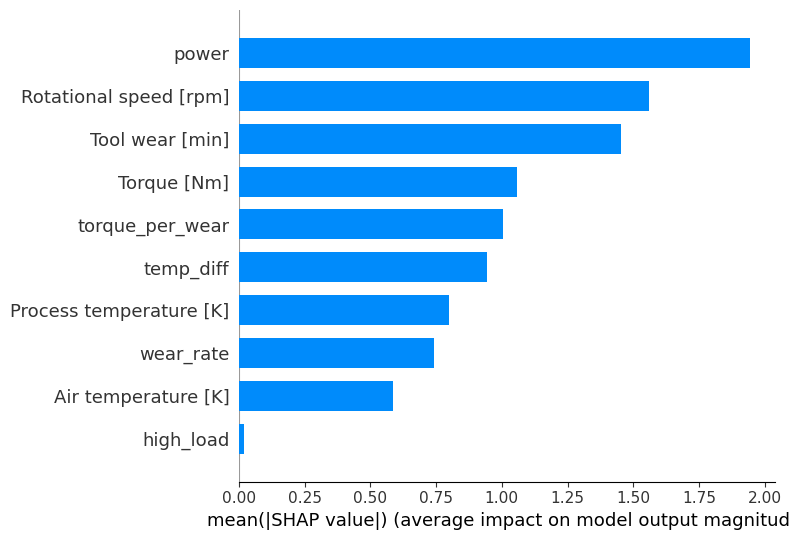

In [4]:
# Global bar plot
shap.summary_plot(shap_values, X_test_df_scaled.iloc[:500], plot_type='bar')
# Expected: Tool wear and Torque at top

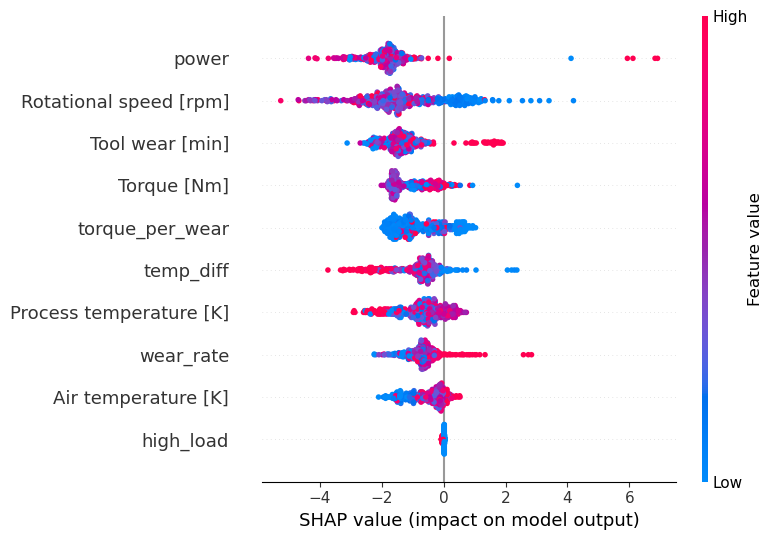

In [5]:
# Summary beeswarm: direction of feature impact
shap.summary_plot(shap_values, X_test_df_scaled.iloc[:500])
# High tool wear = red points on right → increases failure risk
# Low rotational speed = blue points on right → also increases risk (unusual operating regime)

In [6]:
# Individual explanation: find a predicted failure and explain it
proba = clf.predict_proba(X_test)
true_pos_idx = np.where((proba >= clf.optimal_threshold) & (y_test.values == 1))[0]
print(f"True positives: {len(true_pos_idx)}")

# Pick the highest-probability true positive
best_tp = true_pos_idx[np.argmax(proba[true_pos_idx])]
print(f"\nSelected sample idx={best_tp}")
print(f"Failure probability: {proba[best_tp]:.3f}")
print(f"Sensor readings:")
print(X_test.iloc[best_tp])

True positives: 62

Selected sample idx=1949
Failure probability: 1.000
Sensor readings:
Air temperature [K]          301.700000
Process temperature [K]      309.800000
Rotational speed [rpm]      1284.000000
Torque [Nm]                   68.200000
Tool wear [min]              111.000000
temp_diff                      8.100000
power                      87568.800000
wear_rate                      0.086381
torque_per_wear                0.608929
high_load                      1.000000
Name: 4342, dtype: float64


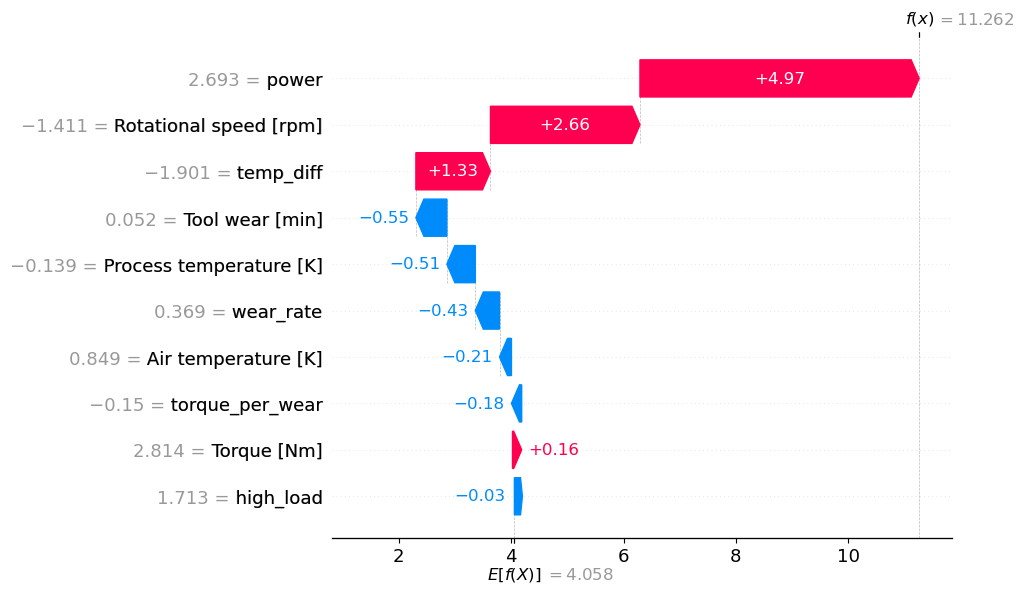

In [7]:
# Waterfall plot for the selected sample
shap_single = explainer.shap_values(X_test_scaled[best_tp:best_tp+1])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0],
        base_values=explainer.expected_value,
        data=X_test_scaled[best_tp],
        feature_names=clf.feature_names,
    )
)
# This is the screenshot for README.md and the interview demo

In [8]:
# Save global importance to figures/
shap_df = pd.DataFrame({
    'feature': clf.feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Global SHAP importance:")
print(shap_df.to_string(index=False))
shap_df.to_csv('../figures/shap_importance.csv', index=False)
# NOTE: tie top features back to mechanical stress and accumulated wear physics in README

Global SHAP importance:
                feature  mean_abs_shap
                  power       1.944100
 Rotational speed [rpm]       1.558613
        Tool wear [min]       1.453304
            Torque [Nm]       1.059128
        torque_per_wear       1.003380
              temp_diff       0.941935
Process temperature [K]       0.797829
              wear_rate       0.743424
    Air temperature [K]       0.585989
              high_load       0.019988
